# Time-Series Anomaly Detection on Machine Temperature

This notebook demonstrates statistical and deep-learning anomaly detection on the NAB `machine_temperature_system_failure` dataset. The goal is to compare robust statistical baselines with neural reconstruction models using point-level and NAB-window evaluation.

## Methods: Theory Summary

**MAD** uses the median absolute deviation as a robust estimate of spread. A point is anomalous when its robust z-score is large: `0.6745 * |x - median| / MAD`.

**IQR** uses the interquartile range between Q1 and Q3. Values outside `Q1 - 1.5*IQR` and `Q3 + 1.5*IQR` are treated as outliers.

**STL** decomposes a time series into trend, seasonal, and residual components. Anomalies are detected on the residual because normal seasonal behavior has been removed.

**Autoencoder** learns to reconstruct normal sliding windows. Windows with high reconstruction error are anomalous because the model fails to reproduce patterns unlike training data.

**Anomaly Transformer** models temporal associations using attention. The original method compares learned series associations with a prior association over time distance; unusual association patterns and reconstruction error contribute to the anomaly score.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.data import load_labeled_series, load_labels, make_train_mask
from src.evaluation import compare_detectors, evaluate_detector, sweep_thresholds
from src.statistical import rolling_mad_detector, rolling_iqr_detector, stl_detector
from src.visualization import plot_series_with_windows, plot_predictions, plot_scores

In [2]:
df = load_labeled_series()
labels = load_labels()
windows = labels["windows"]

print(df.head())
print(df[["timestamp", "value", "is_anomaly"]].describe(include="all"))
print(f"Rows: {len(df):,}")
print(f"Anomaly points: {df['is_anomaly'].sum():,}")
print(f"NAB windows: {len(windows)}")

            timestamp  value  is_point_label  is_anomaly
0 2014-07-01 00:00:00  10844           False       False
1 2014-07-01 00:30:00   8127           False       False
2 2014-07-01 01:00:00   6210           False       False
3 2014-07-01 01:30:00   4656           False       False
4 2014-07-01 02:00:00   3820           False       False
                  timestamp         value is_anomaly
count                 10320  10320.000000      10320
unique                  NaN           NaN          2
top                     NaN           NaN      False
freq                    NaN           NaN       9285
mean    2014-10-16 11:45:00  15137.569380        NaN
min     2014-07-01 00:00:00      8.000000        NaN
25%     2014-08-23 17:52:30  10262.000000        NaN
50%     2014-10-16 11:45:00  16778.000000        NaN
75%     2014-12-09 05:37:30  19838.750000        NaN
max     2015-01-31 23:30:00  39197.000000        NaN
std                     NaN   6939.495808        NaN
Rows: 10,320
Anomaly p

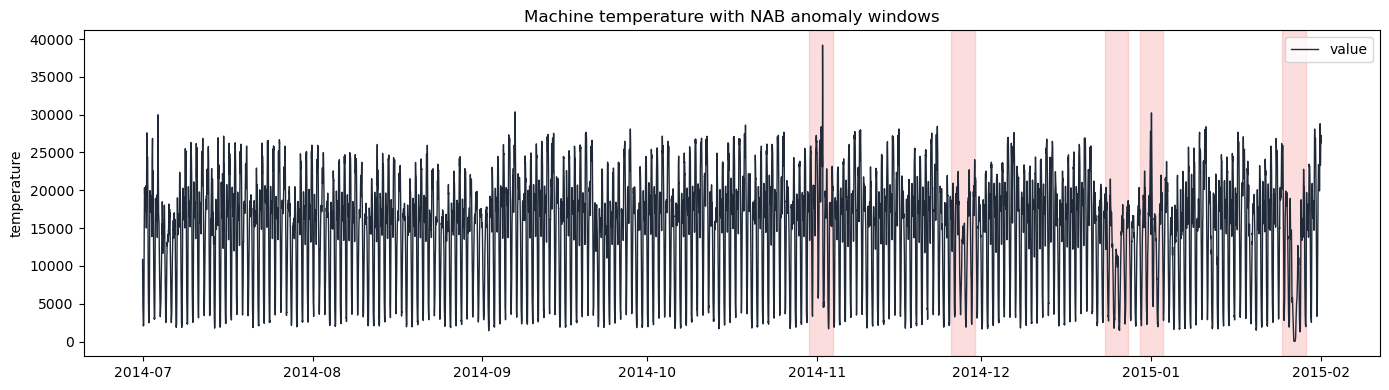

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_series_with_windows(ax, df, windows, title="Machine temperature with NAB anomaly windows")
plt.tight_layout()

## Statistical Detectors

In [4]:
stat_predictions = {
    "MAD": rolling_mad_detector(df, window=288, threshold=3.5),
    "IQR": rolling_iqr_detector(df, window=288, multiplier=1.5),
    "STL": stl_detector(df, period=288, threshold=3.5),
}

stat_rows = [
    evaluate_detector(df, pred, windows, name=name)
    for name, pred in stat_predictions.items()
]
compare_detectors(stat_rows)

,method,precision,recall,f1,pr_auc,roc_auc,predicted_points,windows_detected,windows_total,window_recall,mean_detection_delay_min
2,STL,0.155206,0.305314,0.205796,0.147052,0.581527,2036.0,5.0,5.0,1.0,1056.0
1,IQR,1.000000,0.000966,0.001931,0.144886,0.500483,1.0,1.0,5.0,0.2,3450.0
0,MAD,0.000000,0.000000,0.000000,0.089816,0.491110,0.0,0.0,5.0,0.0,NaN


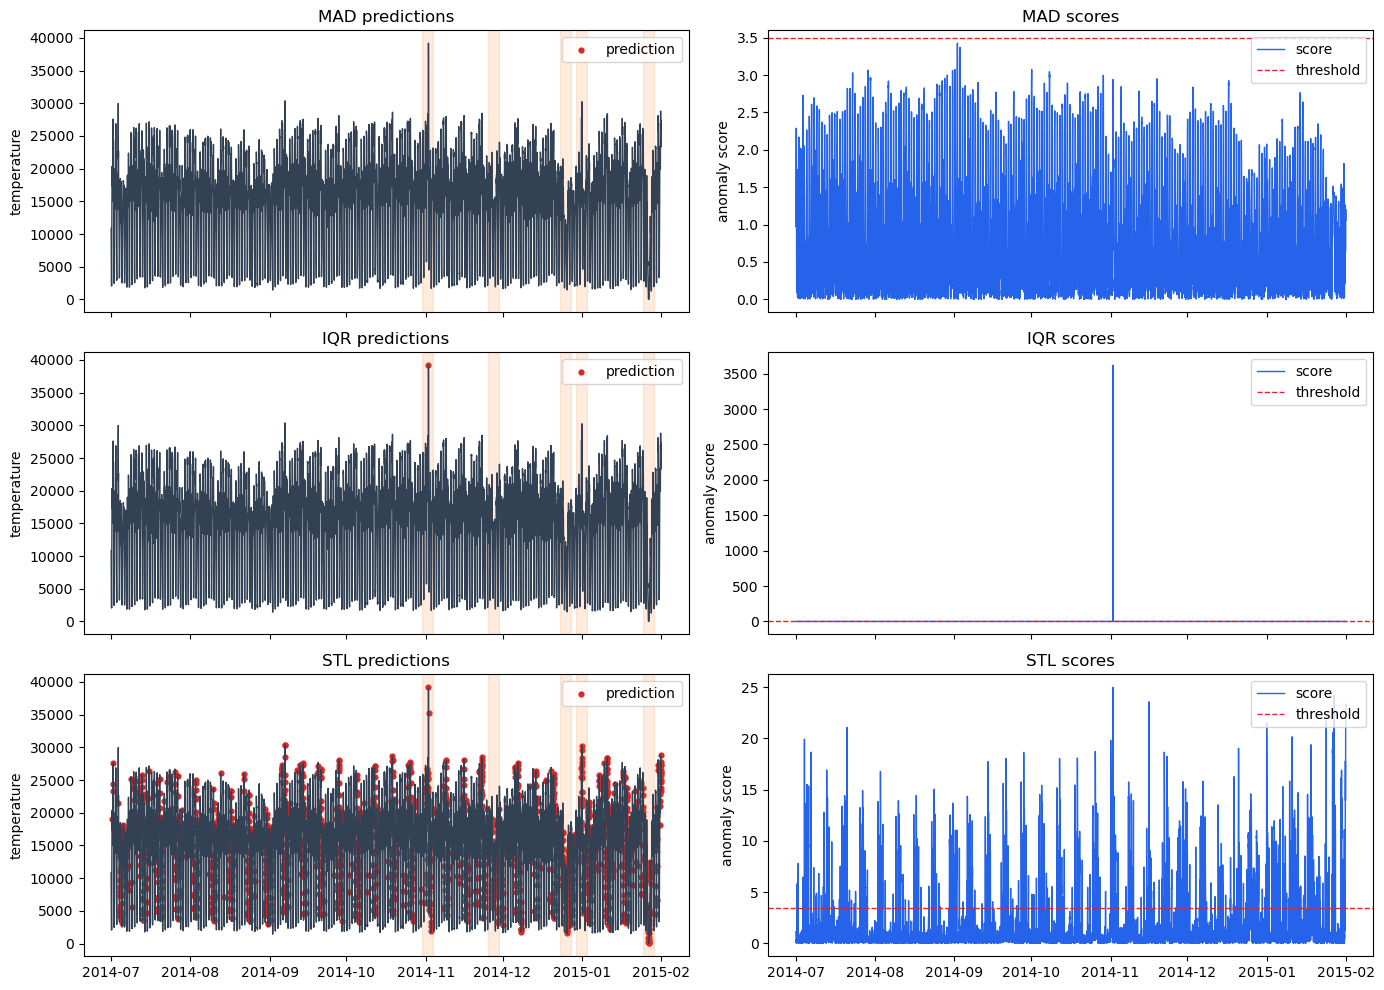

In [5]:
fig, axes = plt.subplots(len(stat_predictions), 2, figsize=(14, 10), sharex="col")
for row, (name, pred) in enumerate(stat_predictions.items()):
    plot_predictions(axes[row, 0], df, pred, windows, title=f"{name} predictions")
    plot_scores(axes[row, 1], pred, title=f"{name} scores")
plt.tight_layout()

## Deep-Learning Detectors

The deep-learning cells train on windows that do not overlap labeled anomaly windows. The defaults use shorter, strided windows so the demo is practical on CPU; increase `DL_WINDOW`, reduce `DL_STRIDE`, or increase epochs for a stronger comparison.

In [6]:
RUN_DEEP_LEARNING = True
DL_WINDOW = 96
DL_STRIDE = 6

dl_predictions = {}
if RUN_DEEP_LEARNING:
    from src.deep_learning import (
        detect_anomaly_transformer,
        detect_autoencoder,
        train_anomaly_transformer,
        train_autoencoder,
    )

    train_mask = make_train_mask(df)

    ae_model, ae_scaler, ae_threshold = train_autoencoder(
        df, train_mask, window_size=DL_WINDOW, stride=DL_STRIDE, epochs=10, threshold_quantile=0.995
    )
    dl_predictions["Autoencoder"] = detect_autoencoder(
        df, ae_model, ae_scaler, ae_threshold, window_size=DL_WINDOW, stride=DL_STRIDE
    )

    at_model, at_scaler, at_threshold = train_anomaly_transformer(
        df, train_mask, window_size=DL_WINDOW, stride=DL_STRIDE, epochs=3, threshold_quantile=0.995
    )
    dl_predictions["Anomaly Transformer"] = detect_anomaly_transformer(
        df, at_model, at_scaler, at_threshold, window_size=DL_WINDOW, stride=DL_STRIDE
    )

c:\Users\admin\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:20: UserWarning: Failed to initialize NumPy: DLL load failed while importing _multiarray_umath: The specified module could not be found. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:84.)
  device: torch.device = torch.device(torch._C._get_default_device()),  # torch.device('cpu'),


In [7]:
all_predictions = {**stat_predictions, **dl_predictions}
all_rows = [
    evaluate_detector(df, pred, windows, name=name)
    for name, pred in all_predictions.items()
]

for name, pred in all_predictions.items():
        score_thresholds = np.quantile(
            pred["score"].astype(float).fillna(0.0),
            [0.90, 0.95, 0.975, 0.98, 0.99, 0.995],
        )
        thresholds = np.unique(
            np.concatenate([score_thresholds, pred["threshold"].astype(float).dropna().unique()])
        )
        sweep = sweep_thresholds(
            df,
            pred,
            windows,
            name=f"{name} calibrated",
            thresholds=thresholds,
        )
        best = sweep.sort_values(["f1", "window_recall"], ascending=False).iloc[0].to_dict()
        all_rows.append(best)

print(compare_detectors(all_rows).to_string(index=False))
results = compare_detectors(all_rows)
results

                        method  threshold  precision   recall       f1   pr_auc  roc_auc  predicted_points  windows_detected  windows_total  window_recall  mean_detection_delay_min
        Autoencoder calibrated   0.180882   0.861434 0.858937 0.860184 0.896177 0.977943            1032.0               5.0            5.0            1.0                     318.0
                   Autoencoder        NaN   0.675477 0.888889 0.767626 0.896177 0.977943            1362.0               5.0            5.0            1.0                     240.0
Anomaly Transformer calibrated   0.013619   0.521318 0.519807 0.520561 0.552681 0.818655            1032.0               3.0            5.0            0.6                     590.0
           Anomaly Transformer        NaN   0.616667 0.357488 0.452599 0.552681 0.818655             600.0               2.0            5.0            0.4                     630.0
                           STL        NaN   0.155206 0.305314 0.205796 0.147052 0.581527       

,method,threshold,precision,recall,f1,pr_auc,roc_auc,predicted_points,windows_detected,windows_total,window_recall,mean_detection_delay_min
8,Autoencoder calibrated,0.180882,0.861434,0.858937,0.860184,0.896177,0.977943,1032.0,5.0,5.0,1.0,318.0
3,Autoencoder,NaN,0.675477,0.888889,0.767626,0.896177,0.977943,1362.0,5.0,5.0,1.0,240.0
9,Anomaly Transformer calibrated,0.013619,0.521318,0.519807,0.520561,0.552681,0.818655,1032.0,3.0,5.0,0.6,590.0
4,Anomaly Transformer,NaN,0.616667,0.357488,0.452599,0.552681,0.818655,600.0,2.0,5.0,0.4,630.0
2,STL,NaN,0.155206,0.305314,0.205796,0.147052,0.581527,2036.0,5.0,5.0,1.0,1056.0
7,STL calibrated,3.500000,0.155206,0.305314,0.205796,0.147052,0.581527,2036.0,5.0,5.0,1.0,1056.0
5,MAD calibrated,2.190722,0.004845,0.004831,0.004838,0.089816,0.491110,1032.0,1.0,5.0,0.2,3450.0
1,IQR,NaN,1.000000,0.000966,0.001931,0.144886,0.500483,1.0,1.0,5.0,0.2,3450.0
6,IQR calibrated,0.000000,1.000000,0.000966,0.001931,0.144886,0.500483,1.0,1.0,5.0,0.2,3450.0
0,MAD,NaN,0.000000,0.000000,0.000000,0.089816,0.491110,0.0,0.0,5.0,0.0,NaN


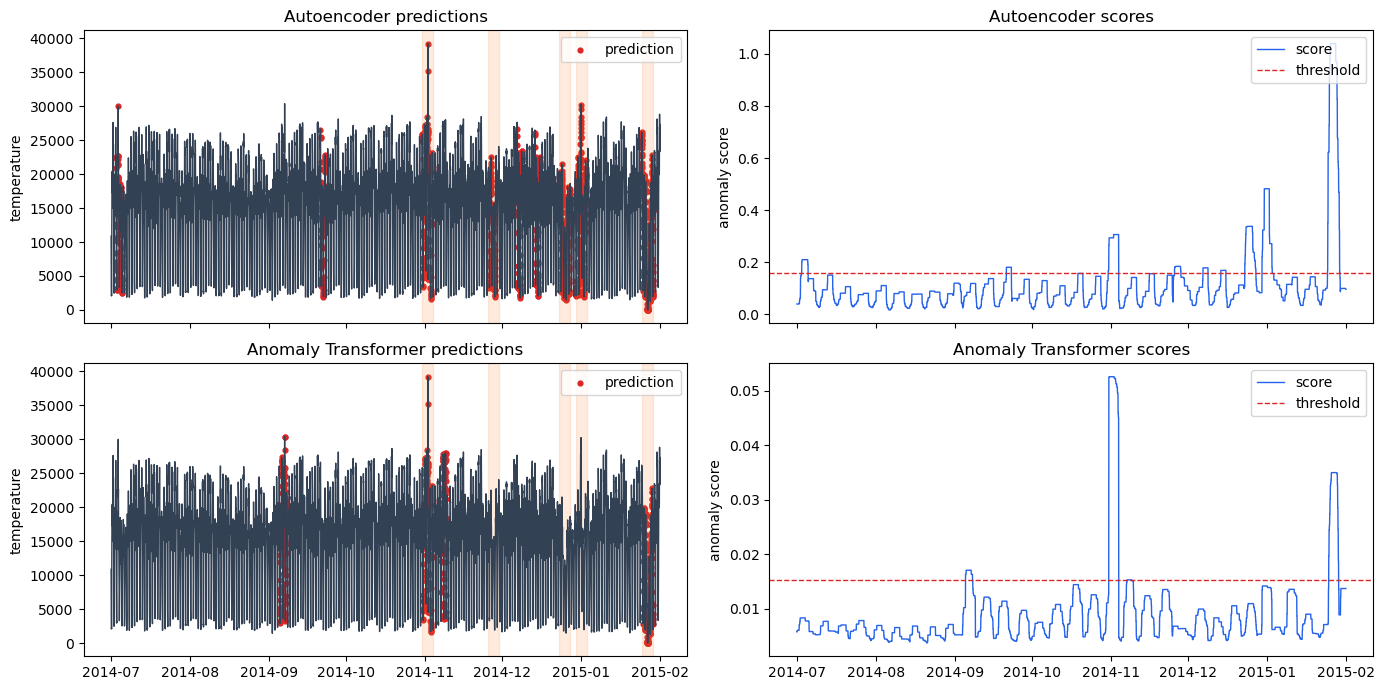

In [8]:
if dl_predictions:
    fig, axes = plt.subplots(len(dl_predictions), 2, figsize=(14, 7), sharex="col")
    if len(dl_predictions) == 1:
        axes = [axes]
    for row, (name, pred) in enumerate(dl_predictions.items()):
        plot_predictions(axes[row][0], df, pred, windows, title=f"{name} predictions")
        plot_scores(axes[row][1], pred, title=f"{name} scores")
    plt.tight_layout()

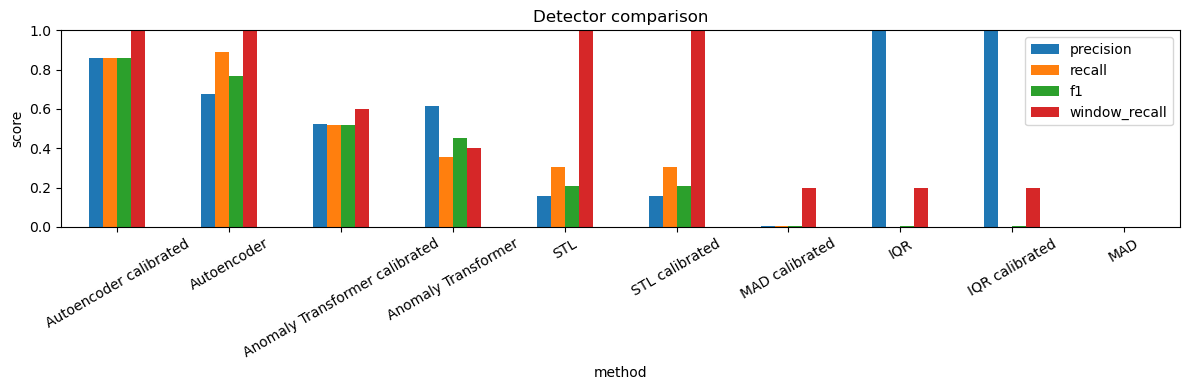

In [9]:
ax = results.set_index("method")[["precision", "recall", "f1", "window_recall"]].plot(
    kind="bar", figsize=(12, 4), ylim=(0, 1), rot=30
)
ax.set_title("Detector comparison")
ax.set_ylabel("score")
plt.tight_layout()